In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("AppleStockPrices.csv")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
df.head()

df['Date'] = pd.to_datetime(df['Date'] , dayfirst=True)
print(df.dtypes)


Shape: (10608, 7)

Data types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [ ]:
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [ ]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


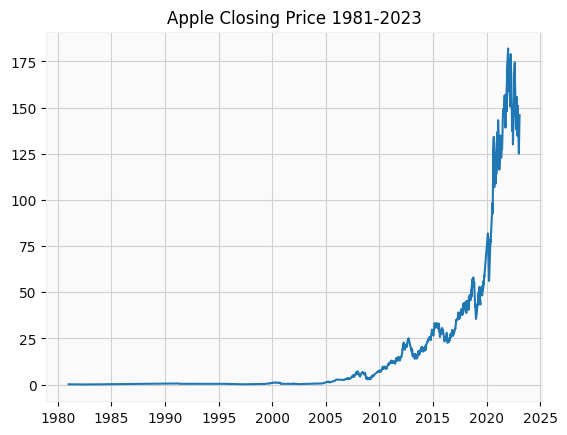

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['Close'])
plt.title('Apple Closing Price 1981-2023')
plt.show()

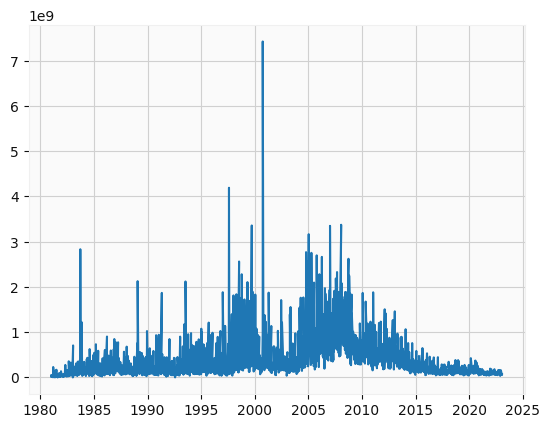

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['Volume'])
plt.show()


In [ ]:
!pip install mplfinance


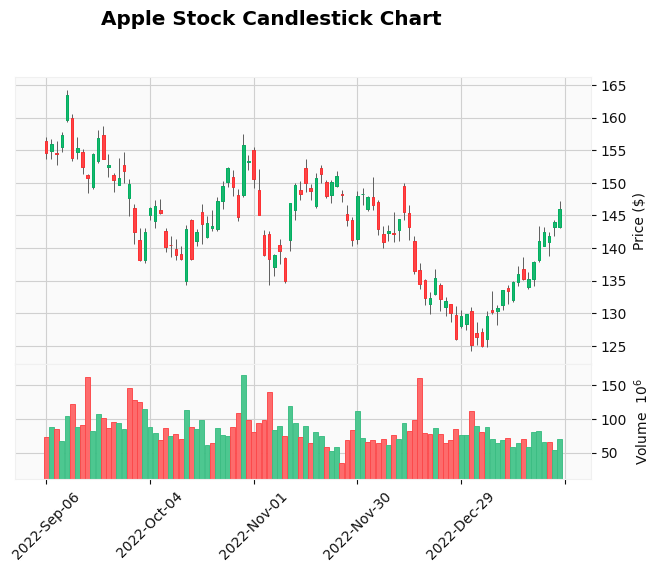

In [ ]:
import mplfinance as mpf
mpf.plot(
    df.tail(100),
    type='candle',
    style='yahoo',
    title='Apple Stock Candlestick Chart',
    ylabel='Price ($)',
    volume=True
)

In [ ]:
print("OPEN")
print("Mean:", df['Open'].mean())
print("Median:", df['Open'].median())
print("Std Dev:", df['Open'].std())

print("\nHIGH")
print("Mean:", df['High'].mean())
print("Median:", df['High'].median())
print("Std Dev:", df['High'].std())

print("\nLOW")
print("Mean:", df['Low'].mean())
print("Median:", df['Low'].median())
print("Std Dev:", df['Low'].std())

print("\nCLOSE")
print("Mean:", df['Close'].mean())
print("Median:", df['Close'].median())
print("Std Dev:", df['Close'].std())

print("\nVOLUME")
print("Mean:", df['Volume'].mean())
print("Median:", df['Volume'].median())
print("Std Dev:", df['Volume'].std())


OPEN
Mean: 16.6891725885181
Median: 0.488839
Std Dev: 35.45051888348929

HIGH
Mean: 16.879955221342385
Median: 0.495536
Std Dev: 35.88284778912029

LOW
Mean: 16.500821578525642
Median: 0.4804465
Std Dev: 35.03128850043324

CLOSE
Mean: 16.69736201451735
Median: 0.487701
Std Dev: 35.47391163938849

VOLUME
Mean: 327509817.26055807
Median: 214597600.0
Std Dev: 337820279.05772716


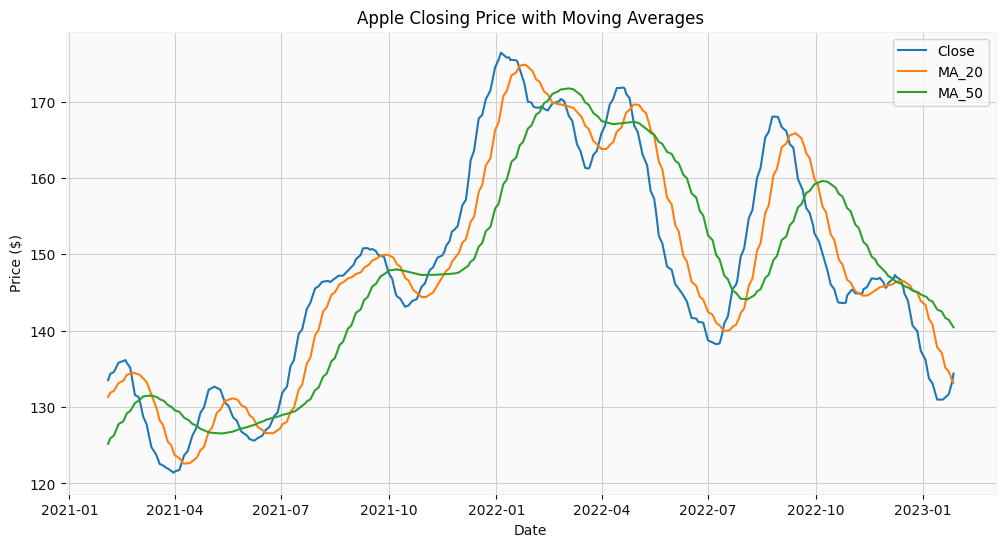

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_recent.index, df_recent['Close'], label='Close')
plt.plot(df_recent.index, df_recent['MA_20'], label='MA_20')
plt.plot(df_recent.index, df_recent['MA_50'], label='MA_50')

plt.title('Apple Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()

plt.show()

The 20-day and 50-day moving averages were calculated using Apple’s closing prices to smooth short-term volatility and reveal broader trends. The 20-day moving average responds more quickly to recent price changes, while the 50-day moving average provides a smoother long-term trend indicator. Comparing these lines against the raw closing price helps visualize momentum shifts and trend direction.

In [ ]:
from scipy import stats

from scipy import stats

v1 = df.loc['2020']['Close']
v2 = df.loc['2023']['Close']

result = stats.ttest_ind(v1, v2)

print(result)

TtestResult(statistic=np.float64(-7.659631572185378), pvalue=np.float64(3.377258582040569e-13), df=np.float64(269.0))


I compared Apple’s closing stock prices from 2020 and 2023 using a t-test to see whether the average prices in those two years were meaningfully different or if the difference could just be random chance.

The p-value came out extremely small, much smaller than 0.05, which is the usual cutoff we use.

This means the difference is very unlikely to be due to random variation, so we reject the idea that the two years had the same average closing price.

In [ ]:
df['Daily_Return'] = df['Close'].pct_change()

df[['Close', 'Daily_Return']].head()

,Close,Daily_Return
Date,,
1981-01-02,0.154018,NaN
1981-01-05,0.150670,-0.021738
1981-01-06,0.143973,-0.044448
1981-01-07,0.137835,-0.042633
1981-01-08,0.135045,-0.020242


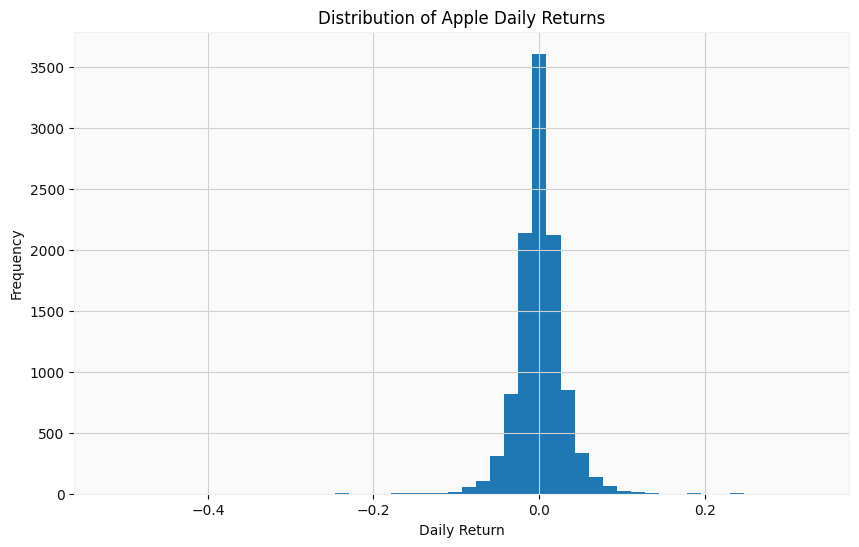

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df['Daily_Return'].dropna(), bins=50)

plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

In [ ]:
from scipy import stats

normality_test = stats.shapiro(df['Daily_Return'].dropna())

print(normality_test)

ShapiroResult(statistic=np.float64(0.9190583946174027), pvalue=np.float64(1.7898289463728573e-59))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10607.
  res = hypotest_fun_out(*samples, **kwds)


I tested whether Apple’s daily stock returns follow a normal (bell-shaped) distribution using the Shapiro-Wilk test.

The p-value was extremely small, far below 0.05, which means the data does not behave like a perfect normal distribution.

Although the histogram looked somewhat bell-shaped, the statistical test suggests Apple’s daily returns contain unusual movements and outliers, which is common in financial markets.